<a href="https://colab.research.google.com/github/Jormao2025/Data_Science_1/blob/main/Proyecto_Final_Data_Science_III_An%C3%A1lisis_Sentimiento_en_Tweets_sobre_Vacunas_contra_COVID_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Análisis de Sentimiento en Tweets sobre Vacunas contra COVID-19

## 1- Introducción
La pandemia de COVID-19 generó un impacto significativo a nivel global, no solo en términos sanitarios sino también en la forma en que las personas intercambian información y opiniones a través de plataformas digitales. En este contexto, las redes sociales se convirtieron en uno de los principales espacios donde los usuarios expresaron percepciones, preocupaciones y opiniones respecto al desarrollo y distribución de las vacunas contra el virus.

Twitter, en particular, representa una fuente valiosa de información para el análisis de la opinión pública, ya que permite observar reacciones inmediatas frente a eventos de relevancia social. El análisis de estas publicaciones puede contribuir a comprender tendencias de percepción social, identificar preocupaciones comunes y evaluar el impacto de las campañas de comunicación relacionadas con la salud pública.

El Procesamiento de Lenguaje Natural (NLP) y las técnicas de Machine Learning permiten analizar grandes volúmenes de texto provenientes de redes sociales de manera automatizada. Una de las aplicaciones más relevantes dentro de este campo es el análisis de sentimiento, que permite identificar si un texto expresa una opinión positiva, negativa o neutral.

En este proyecto se utilizarán técnicas de procesamiento de lenguaje natural y aprendizaje automático para analizar tweets relacionados con las vacunas contra la COVID-19 y clasificar automáticamente el sentimiento presente en dichos mensajes.

## 2- Problema de negocio

Las redes sociales generan diariamente grandes volúmenes de información que reflejan la percepción y opinión de los usuarios frente a diferentes acontecimientos. Analizar manualmente este tipo de contenido resulta complejo debido a la cantidad de datos disponibles y a la velocidad con la que se producen nuevas publicaciones.

En el contexto de las vacunas contra la COVID-19, comprender la opinión de los usuarios puede aportar información relevante sobre la aceptación social de las campañas de vacunación y las percepciones de la población frente a distintos laboratorios y desarrollos farmacéuticos.

El desafío consiste en procesar y analizar automáticamente miles de publicaciones textuales para identificar el sentimiento asociado a cada mensaje, utilizando herramientas de análisis de texto y modelos de aprendizaje automático capaces de clasificar la polaridad de los tweets.

## 3- Objetivo general

Desarrollar un modelo de clasificación de sentimientos aplicado a tweets relacionados con las vacunas contra la COVID-19, utilizando técnicas de procesamiento de lenguaje natural y aprendizaje supervisado con el fin de identificar automáticamente la polaridad de las opiniones expresadas en las publicaciones.

## 4- Objetivos específicos

- Analizar la estructura y características del conjunto de datos utilizado en el estudio.

- Aplicar técnicas de preprocesamiento de texto para limpiar y normalizar el contenido de los tweets.

- Explorar patrones presentes en el texto mediante análisis de frecuencia de palabras, n-gramas y visualizaciones.

- Transformar los textos en representaciones numéricas mediante técnicas de vectorización como TF-IDF o Bag of Words.

- Entrenar un modelo de aprendizaje supervisado para clasificar los tweets según su sentimiento.

- Evaluar el desempeño del modelo utilizando métricas de clasificación y analizar los resultados obtenidos.

## 5- Origen de los datos
El conjunto de datos utilizado en este proyecto proviene del repositorio público Kaggle, específicamente del dataset denominado COVID-19 Vaccine Tweets with Sentiment Annotation https://www.kaggle.com/datasets/datasciencetool/covid19-vaccine-tweets-with-sentiment-annotation?resource=download.
Este dataset contiene una recopilación de tweets relacionados con diferentes vacunas contra la COVID-19, los cuales fueron anotados manualmente con información de sentimiento.

Los identificadores de los tweets fueron obtenidos a partir de un conjunto de datos desarrollado por Gabriel Preda, a partir del cual se recuperó el texto completo de cada publicación. El dataset incluye tweets vinculados a diversas vacunas desarrolladas durante la pandemia, entre ellas Pfizer/BioNTech, Moderna, Oxford/AstraZeneca, Sinopharm, Sinovac, Covaxin y Sputnik V.

Cada tweet posee una etiqueta de sentimiento que indica la polaridad del mensaje, codificada de la siguiente manera:

1 → sentimiento negativo

2 → sentimiento neutral

3 → sentimiento positivo

Esta información permite utilizar el conjunto de datos para tareas de clasificación supervisada, entrenando modelos capaces de identificar automáticamente el sentimiento de nuevas publicaciones en redes sociales.

## 6- Definición de las variables

El dataset utilizado contiene las siguientes variables:

| Variable | Tipo | Descripción |
|---|---|---|
| `tweet_text` | string | Texto original del tweet publicado por el usuario en Twitter/X |
| `label` | entero (1, 2, 3) | Etiqueta de sentimiento asignada manualmente: 1 = Negativo, 2 = Neutral, 3 = Positivo |
| `sentiment` | string (categórica) | Variable derivada de `label`, con valores legibles: "Negativo", "Neutral", "Positivo" |
| `tweet_length` | entero | Variable creada durante el EDA. Representa la cantidad de caracteres del tweet original |
| `clean_text` | string | Variable derivada del preprocesamiento NLP: texto limpio, tokenizado, sin stopwords y lematizado |

**Variable objetivo (target):** `label` / `sentiment` — indica la polaridad del tweet y es la variable que los modelos buscan predecir.

**Variable predictora principal:** `clean_text` — texto preprocesado que se transforma en representaciones numéricas (TF-IDF, BOW, secuencias) para alimentar los modelos.

## 7- Librerías utilizadas
Para el desarrollo del proyecto se utilizaron diversas librerías del ecosistema Python orientadas al análisis de datos, procesamiento de texto y aprendizaje automático.

Las principales herramientas utilizadas incluyen:

- Pandas y NumPy para manipulación y análisis de datos.

- Matplotlib y Seaborn para visualización de información.

- NLTK para tareas de procesamiento de lenguaje natural como tokenización, eliminación de stopwords y lematización.

- Scikit-learn para técnicas de vectorización de texto, partición de datos, entrenamiento de modelos y evaluación de métricas.

- WordCloud para visualizaciones de frecuencia de palabras.

- TensorFlow / Keras para la implementación del modelo de Deep Learning basado en BiLSTM.

- vaderSentiment para análisis de sentimiento exploratorio no supervisado mediante enfoque léxico.


In [1]:
# Importación de Librerías
import os
import re
import random
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# CONFIGURACIÓN GENERAL

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Recursos de NLTK
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("Librerías cargadas correctamente.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Librerías cargadas correctamente.


## 8- Carga y preparación del dataset

In [2]:
import requests

url = "https://github.com/Jormao2025/Data_Science_1/raw/refs/heads/main/covid-19_vaccine_tweets_with_sentiment1.csv"

response = requests.get(url)  # Hace una solicitud GET para obtener el contenido del archivo
print(response.text[:300])  # Imprime los primeros 300 caracteres del archivo para ver cómo está delimitado

df = pd.read_csv(url, sep=';', encoding='latin1')

df = df.loc[:, ~df.columns.str.contains('^Unnamed')].copy()

temp = df['tweet_id,label,tweet_text'].str.split(',', n=2, expand=True)

df['tweet_id'] = temp[0]
df['label'] = temp[1]
df['tweet_text'] = temp[2]

df = df[['tweet_id','label','tweet_text']].copy()

df['label'] = pd.to_numeric(df['label'], errors='coerce')

df.dropna(inplace=True)

df = df[['tweet_text','label']].copy()

df.head()



tweet_id,label,tweet_text;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;
"1360342002961940483,1,""4,000 a day dying from the so called Covid-19 “vaccine” @DailyBeast reports. #vaccine #PfizerVaccine #Moderna  ";;;;;" """"https://t.co/p1nQWWZ


,tweet_text,label
0,"""4,000 a day dying from the so called Covid-19...",1
1,Pranam message for today manifested in Dhyan b...,2
2,"""Hyderabad-based ?@BharatBiotech? has sought f...",2
3,"""Confirmation that Chinese #vaccines """"""""""""""""d...",1
4,"""Lab studies suggest #Pfizer, #Moderna vaccine...",3


## 9- Análisis exploratorio de datos (EDA)
En esta etapa se analiza la estructura del dataset, la distribución de las etiquetas de sentimiento y algunas características básicas del texto. Este análisis permite identificar posibles desbalances entre las clases y comprender mejor el contenido de los tweets.

9.1 Distribución de sentimientos

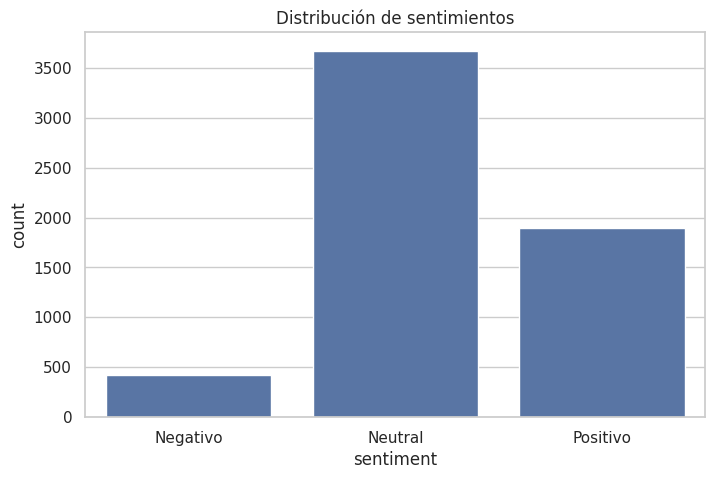

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

label_map = {1:'Negativo',2:'Neutral',3:'Positivo'}
df['sentiment'] = df['label'].map(label_map)

sns.countplot(x='sentiment', data=df)
plt.title("Distribución de sentimientos")
plt.show()

El análisis exploratorio mostró un fuerte desbalance entre clases, con predominio de tweets neutrales. Esta característica condiciona el comportamiento de los modelos y explica por qué la accuracy aislada no resulta suficiente para evaluar el desempeño. Por ello, fue necesario complementar la evaluación con F1-score y matriz de confusión.

### 9.2 Longitud de tweets

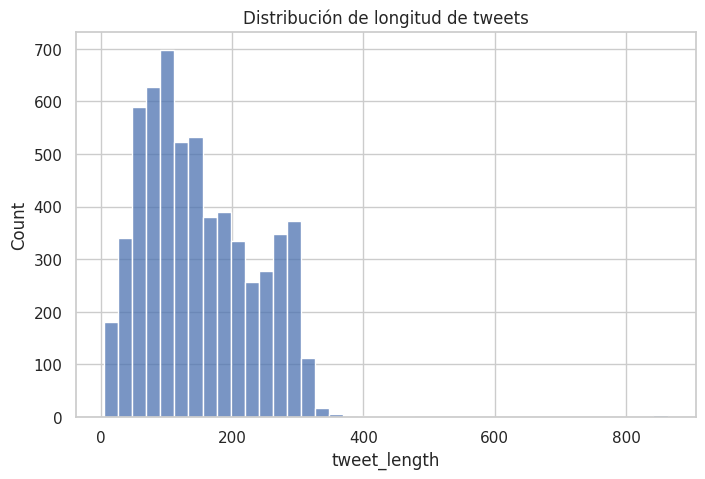

In [4]:
df['tweet_length'] = df['tweet_text'].astype(str).apply(len)

sns.histplot(df['tweet_length'], bins=40)
plt.title("Distribución de longitud de tweets")
plt.show()

### 9.3 Balance de clases en porcentaje

Además de analizar la cantidad absoluta de tweets por categoría de sentimiento, resulta útil observar la distribución porcentual de las clases. Esto permite identificar si existe un desbalance en el dataset entre tweets negativos, neutrales y positivos, lo cual podría influir en el desempeño del modelo de clasificación.

Un conjunto de datos muy desbalanceado puede generar modelos que tienden a predecir con mayor frecuencia la clase mayoritaria. Por esta razón, se analiza la proporción relativa de cada categoría de sentimiento.

In [5]:
# Cantidad de tweets por clase
label_counts = df['sentiment'].value_counts()

# Porcentaje por clase
label_percent = df['sentiment'].value_counts(normalize=True) * 100

print("Cantidad por clase:\n")
print(label_counts)

print("\nPorcentaje por clase:\n")
print(label_percent.round(2))

Cantidad por clase:

sentiment
Neutral     3672
Positivo    1898
Negativo     420
Name: count, dtype: int64

Porcentaje por clase:

sentiment
Neutral     61.30
Positivo    31.69
Negativo     7.01
Name: proportion, dtype: float64


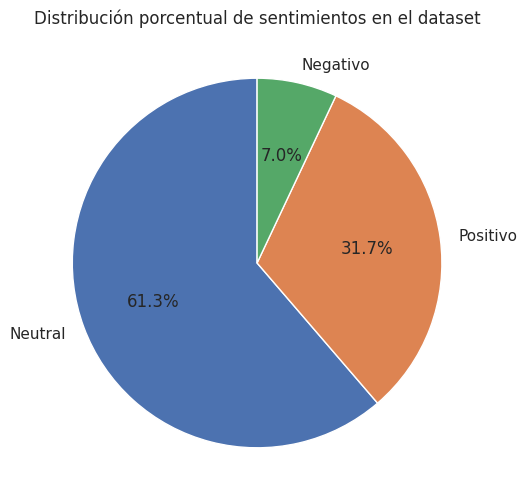

In [6]:
plt.figure(figsize=(6,6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Distribución porcentual de sentimientos en el dataset")
plt.show()

### 9.4 Ejemplos de tweets por clase
Con el objetivo de comprender mejor las características del corpus analizado, se presentan algunos ejemplos representativos de tweets pertenecientes a cada categoría de sentimiento. Este análisis cualitativo permite observar diferencias en el tipo de lenguaje utilizado en publicaciones negativas, neutrales y positivas.

La revisión manual de ejemplos también resulta útil para validar la coherencia de las etiquetas del dataset y comprender mejor el contexto de las discusiones relacionadas con las vacunas contra la COVID-19.

In [7]:
print("Ejemplos de tweets negativos:\n")
print(df[df['sentiment'] == 'Negativo']['tweet_text'].head(3))

print("\nEjemplos de tweets neutrales:\n")
print(df[df['sentiment'] == 'Neutral']['tweet_text'].head(3))

print("\nEjemplos de tweets positivos:\n")
print(df[df['sentiment'] == 'Positivo']['tweet_text'].head(3))

Ejemplos de tweets negativos:

0    "4,000 a day dying from the so called Covid-19...
3    "Confirmation that Chinese #vaccines """"""""d...
5        "Still want to take the #jab? #PfizerBioNTech
Name: tweet_text, dtype: object

Ejemplos de tweets neutrales:

1    Pranam message for today manifested in Dhyan b...
2    "Hyderabad-based ?@BharatBiotech? has sought f...
6    "This time, AerolÃ­neas flight AR1068 goes to ...
Name: tweet_text, dtype: object

Ejemplos de tweets positivos:

4    "Lab studies suggest #Pfizer, #Moderna vaccine...
7    "#Covaxin effective against mutant virus strai...
8               Safe and effective. #OxfordAstraZeneca
Name: tweet_text, dtype: object


### 9.5 Longitud de tweets por sentimiento
Además de analizar la distribución general de la longitud de los tweets, resulta interesante explorar si existen diferencias en la extensión de los mensajes según el tipo de sentimiento expresado.

Este análisis permite identificar si ciertos tipos de opiniones tienden a expresarse mediante mensajes más extensos o más breves, lo cual puede aportar información adicional sobre el comportamiento del discurso en redes sociales.

In [8]:
df.groupby('sentiment')['tweet_length'].agg(['mean','median','min','max'])

,mean,median,min,max
sentiment,,,,
Negativo,154.838095,144.0,8,339
Neutral,150.331972,134.0,5,863
Positivo,149.355638,136.0,5,463


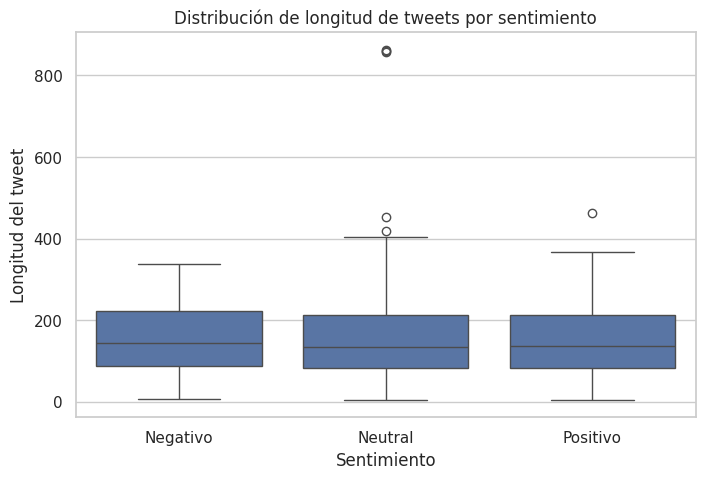

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='sentiment',
    y='tweet_length',
    order=['Negativo','Neutral','Positivo']
)

plt.title("Distribución de longitud de tweets por sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Longitud del tweet")
plt.show()

# Desarrollo - Etapa 1: Procesamiento de Lenguaje Natural (NLP)

En esta etapa se aplican las principales técnicas de procesamiento de lenguaje
natural sobre el corpus de tweets. El objetivo es limpiar, normalizar y explorar
el contenido textual del dataset, preparando los datos para la etapa de
vectorización y modelado.

## 10- Procesamiento de Lenguaje Natural (NLP)
En esta etapa se aplican técnicas de preprocesamiento de lenguaje natural con el objetivo de limpiar y normalizar los tweets. Este paso es fundamental para reducir ruido en el texto y mejorar la calidad de las representaciones numéricas que se utilizarán posteriormente en el modelo de clasificación.

Las principales tareas aplicadas incluyen:

- conversión a minúsculas

- eliminación de URLs

- eliminación de menciones y símbolos innecesarios

- eliminación de puntuación y números

- eliminación de stopwords

- lematización

### 10.1 Instalación e importación de librerías

In [10]:
!pip install nltk wordcloud -q

In [17]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

### 10.2 Descarga de recursos de NLTK

In [16]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### 10.3 Crear stopwords y lematizador

In [15]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

### 10.4 Aplicar función de limpieza

In [13]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)   # eliminar urls
    text = re.sub(r'@\w+', '', text)                      # eliminar menciones
    text = re.sub(r'#', '', text)                         # quitar símbolo hashtag
    text = re.sub(r'\d+', '', text)                       # quitar números
    text = text.translate(str.maketrans('', '', string.punctuation))  # quitar puntuación

    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

### 10.5 Aplicar limpieza al dataset

In [18]:
df['clean_text'] = df['tweet_text'].apply(clean_text)

### 10.6 Verificar que la columna se creó bien

In [19]:
print(df.columns)
print(df[['tweet_text', 'clean_text']].head())

Index(['tweet_text', 'label', 'sentiment', 'tweet_length', 'clean_text'], dtype='object')
                                          tweet_text  \
0  "4,000 a day dying from the so called Covid-19...   
1  Pranam message for today manifested in Dhyan b...   
2  "Hyderabad-based ?@BharatBiotech? has sought f...   
3  "Confirmation that Chinese #vaccines """"""""d...   
4  "Lab studies suggest #Pfizer, #Moderna vaccine...   

                                          clean_text  
0  day dying called covid âvaccineâ report va...  
1  pranam message today manifested dhyan truth lo...  
2  hyderabadbased sought fund government ramp pro...  
3  confirmation chinese vaccine donât high prot...  
4  lab study suggest pfizer moderna vaccine prote...  


## 11- Visualización de texto

### 11.1 Nube de palabras general

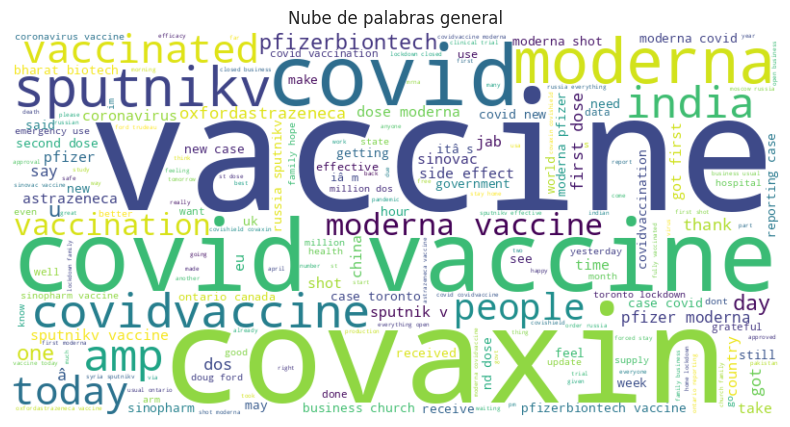

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_all = " ".join(df['clean_text'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_all)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de palabras general")
plt.show()

### 11.2 Nube de palabras por sentimiento

In [21]:
label_map = {1: 'Negativo', 2: 'Neutral', 3: 'Positivo'}
df['sentiment'] = df['label'].map(label_map)

#### Negativo

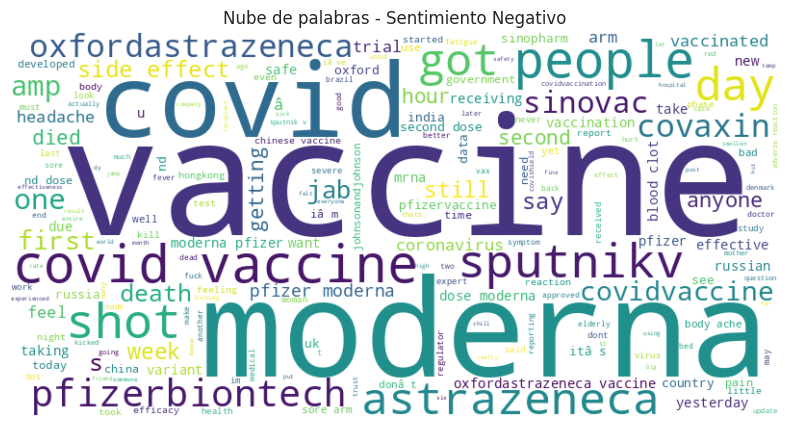

In [22]:
text_neg = " ".join(df[df['sentiment'] == 'Negativo']['clean_text'].dropna())

wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(text_neg)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de palabras - Sentimiento Negativo")
plt.show()

#### Neutral

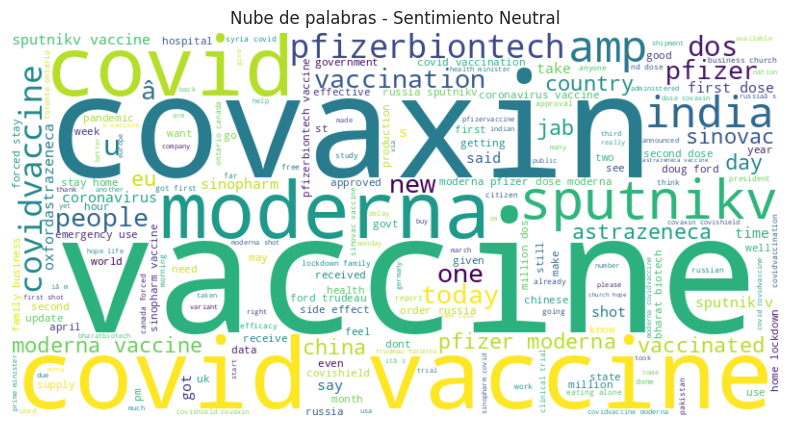

In [23]:
text_neu = " ".join(df[df['sentiment'] == 'Neutral']['clean_text'].dropna())

wordcloud_neu = WordCloud(width=800, height=400, background_color='white').generate(text_neu)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neu, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de palabras - Sentimiento Neutral")
plt.show()

#### Positivo

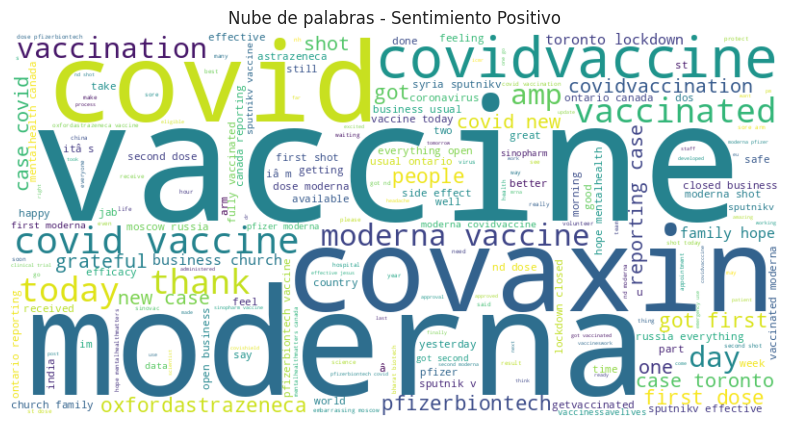

In [24]:
text_pos = " ".join(df[df['sentiment'] == 'Positivo']['clean_text'].dropna())

wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(text_pos)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Nube de palabras - Sentimiento Positivo")
plt.show()

## 12- N-gramas

Además del análisis de frecuencia de palabras individuales, se analizaron combinaciones de palabras consecutivas (n-gramas), ya que estas pueden aportar mayor contexto semántico que los términos aislados.

### 12. 1 Unigramas más frecuentes

Una de las técnicas que nos resulta útil explorar son los unigramas más frecuentes dentro del corpus de tweets.

Los unigramas corresponden a palabras individuales y permiten identificar los términos que aparecen con mayor frecuencia en el conjunto de datos.

Este análisis ayuda a comprender cuáles son los conceptos o palabras más mencionadas en las conversaciones relacionadas con las vacunas contra la COVID-19.

In [25]:
from sklearn.feature_extraction.text import CountVectorizer

unigram_vectorizer = CountVectorizer(ngram_range=(1,1), max_features=10)
X_unigrams = unigram_vectorizer.fit_transform(df['clean_text'])

### 12. 2 Bigramas más frecuentes

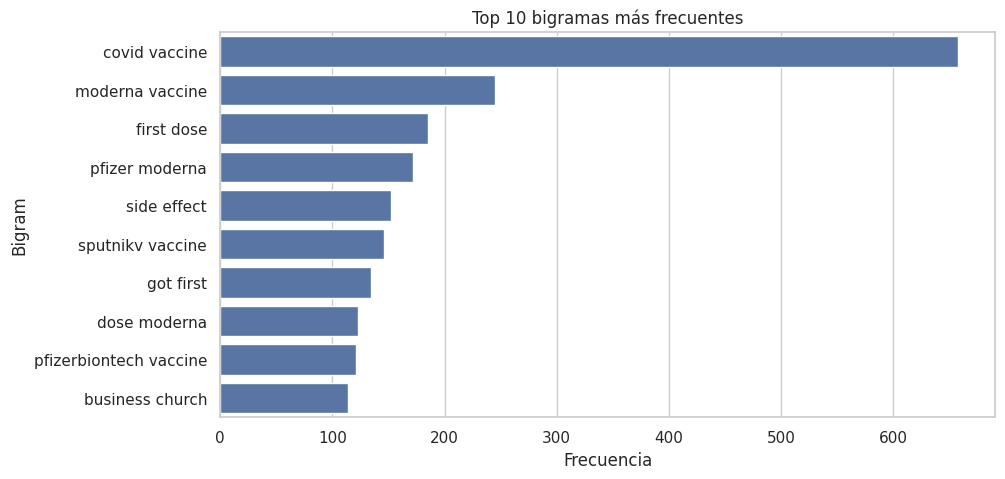

In [26]:
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), max_features=10)
X_bigrams = bigram_vectorizer.fit_transform(df['clean_text'])

sum_words = X_bigrams.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in bigram_vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

bigram_df = pd.DataFrame(words_freq, columns=['Bigram', 'Frecuencia'])

plt.figure(figsize=(10,5))
sns.barplot(data=bigram_df, x='Frecuencia', y='Bigram')
plt.title('Top 10 bigramas más frecuentes')
plt.show()

### 12. 3 Trigramas más frecuentes

Para complementar el análisis de unigramas y bigramas, también se analizan los trigramas más frecuentes. Los trigramas corresponden a secuencias de tres palabras consecutivas, lo que permite capturar expresiones más completas y contextuales dentro del texto.

Este análisis puede revelar frases o combinaciones de palabras que aparecen con frecuencia en las discusiones sobre las vacunas.

In [27]:
# Vectorizador para trigramas
trigram_vectorizer = CountVectorizer(ngram_range=(3,3), max_features=10)

X_trigrams = trigram_vectorizer.fit_transform(df['clean_text'])

# Sumar frecuencia
sum_words_tri = X_trigrams.sum(axis=0)

words_freq_tri = [
    (word, sum_words_tri[0, idx])
    for word, idx in trigram_vectorizer.vocabulary_.items()
]

# Ordenar
words_freq_tri = sorted(words_freq_tri, key=lambda x: x[1], reverse=True)

# Crear dataframe
trigram_df = pd.DataFrame(words_freq_tri, columns=['Trigrama', 'Frecuencia'])

trigram_df

,Trigrama,Frecuencia
0,covid new case,97
1,new case toronto,97
2,reporting case covid,96
3,case covid new,96
4,case toronto lockdown,69
5,toronto lockdown closed,69
6,lockdown closed business,69
7,closed business church,69
8,business church family,69
9,church family hope,69


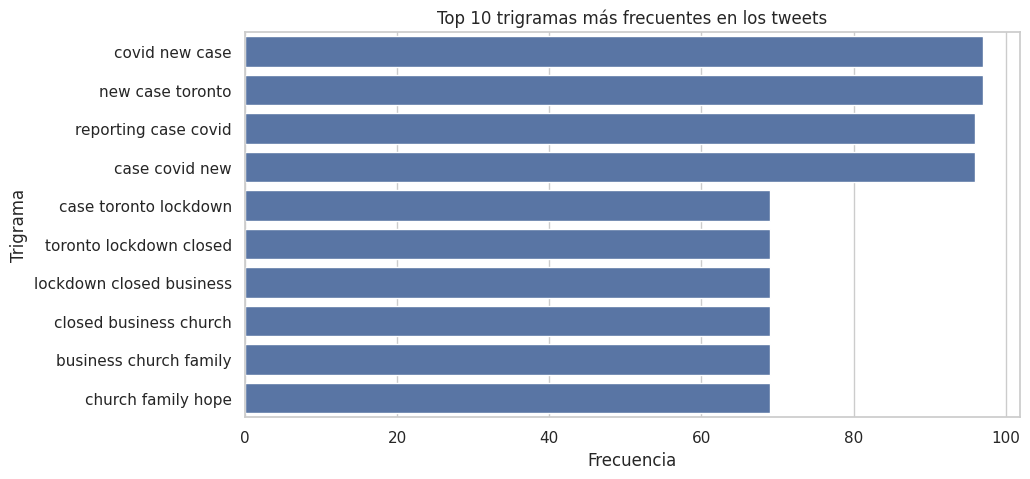

In [28]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=trigram_df,
    x='Frecuencia',
    y='Trigrama'
)

plt.title('Top 10 trigramas más frecuentes en los tweets')
plt.xlabel('Frecuencia')
plt.ylabel('Trigrama')

plt.show()

### 12.4 Top N-gramas por sentimiento

Además del análisis general de unigramas, bigramas y trigramas, resulta útil examinar qué combinaciones de palabras aparecen con mayor frecuencia dentro de cada categoría de sentimiento. Este enfoque permite identificar patrones lingüísticos específicos asociados a tweets negativos, neutrales y positivos.

De esta manera, no solo se describen los términos más frecuentes del corpus en general, sino también aquellas expresiones que caracterizan cada polaridad de sentimiento.

In [29]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
def get_top_ngrams_by_sentiment(data, sentiment_value, ngram_range=(2,2), top_n=10):
    subset = data[data['sentiment'] == sentiment_value]['clean_text'].dropna()

    vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=top_n)
    X = vectorizer.fit_transform(subset)

    sum_words = X.sum(axis=0)
    words_freq = [
        (word, sum_words[0, idx])
        for word, idx in vectorizer.vocabulary_.items()
    ]

    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    col_name = "N-grama"
    return pd.DataFrame(words_freq, columns=[col_name, "Frecuencia"])

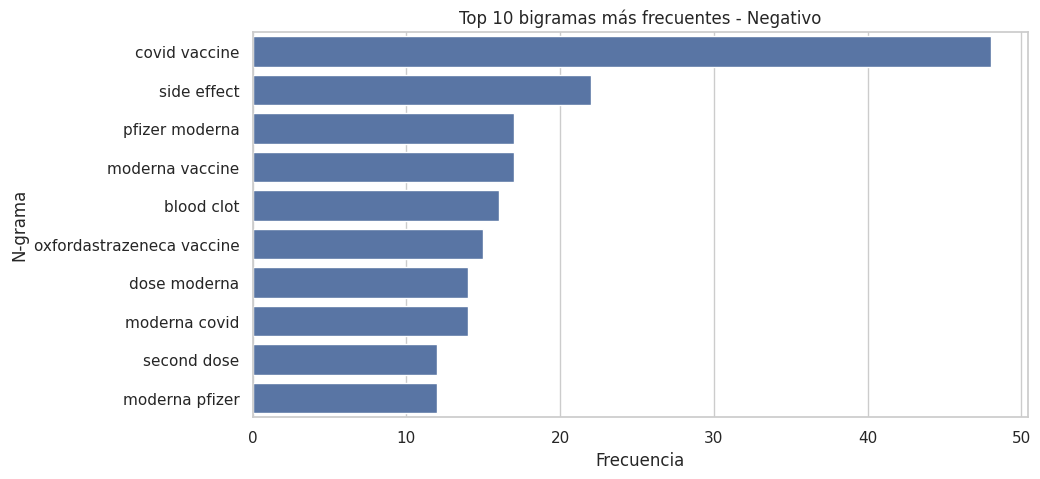

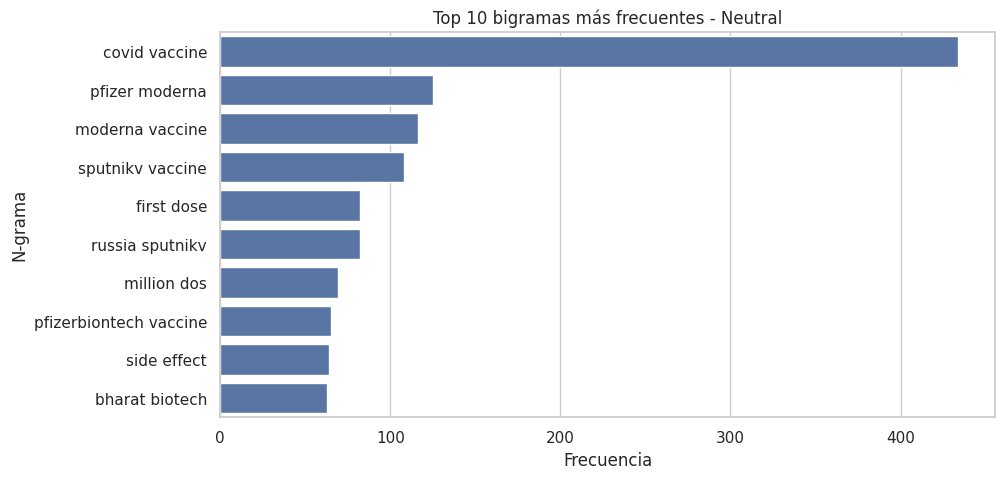

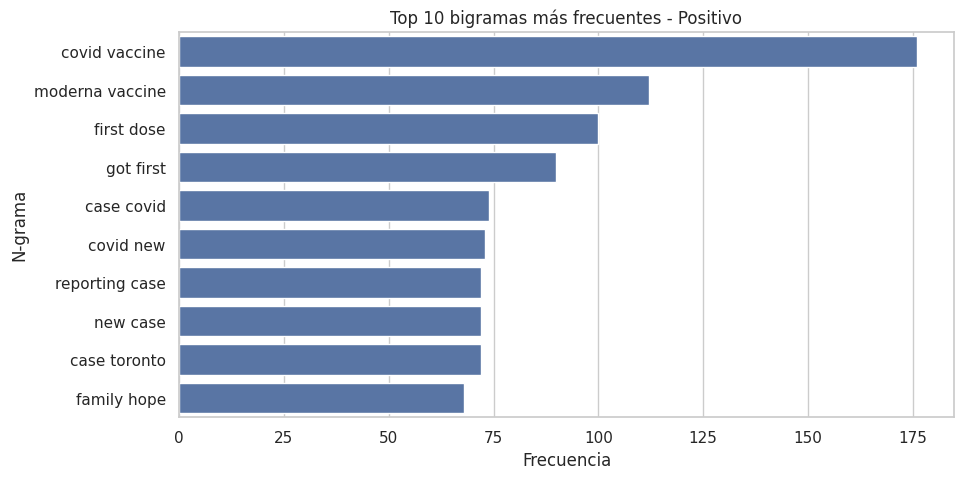

In [31]:
sentiments = ['Negativo', 'Neutral', 'Positivo']

for sentiment_name in sentiments:
    top_df = get_top_ngrams_by_sentiment(df, sentiment_name, ngram_range=(2,2), top_n=10)

    plt.figure(figsize=(10,5))
    sns.barplot(data=top_df, x='Frecuencia', y='N-grama')
    plt.title(f'Top 10 bigramas más frecuentes - {sentiment_name}')
    plt.show()

El análisis de n-gramas por categoría de sentimiento permitió identificar combinaciones de palabras características de cada polaridad. En los tweets negativos tienden a aparecer expresiones asociadas a preocupación, riesgo o rechazo, mientras que en los tweets positivos predominan términos vinculados a aprobación, seguridad o efectividad. En el caso de los tweets neutrales, suelen observarse expresiones más informativas o descriptivas, con menor carga emocional.

Este tipo de análisis enriquece la interpretación del corpus, ya que permite comprender no solo la frecuencia global de las palabras, sino también las diferencias lingüísticas entre los distintos grupos de sentimiento.

## 13- Análisis de sentimiento exploratorio con VADER

Como complemento al análisis supervisado, se aplica VADER (Valence Aware Dictionary and sEntiment Reasoner), una librería léxica diseñada específicamente para textos de redes sociales. A diferencia del modelo de clasificación, VADER no requiere entrenamiento: asigna un puntaje de sentimiento basándose en un diccionario de palabras con polaridad predefinida.

Este análisis permite:
- Comparar el sentimiento detectado automáticamente por VADER con las etiquetas originales del dataset.
- Evaluar si una herramienta no supervisada puede aproximarse al sentimiento anotado manualmente.
- Obtener una perspectiva adicional sobre el corpus antes de entrenar los modelos supervisados.

El compound score de VADER varía entre -1 (muy negativo) y +1 (muy positivo). La convención de clasificación utilizada es:
- compound ≥ 0.05 → Positivo
- compound ≤ -0.05 → Negativo
- entre -0.05 y 0.05 → Neutral

In [32]:
# Instalación e importación de VADER
!pip install vaderSentiment -q

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

# Función para clasificar con VADER usando el compound score
def vader_sentiment(text):
    score = analyzer.polarity_scores(str(text))['compound']
    if score >= 0.05:
        return 'Positivo'
    elif score <= -0.05:
        return 'Negativo'
    else:
        return 'Neutral'

# Aplicar al texto original (no al clean_text, VADER funciona mejor con texto natural)
df['vader_sentiment'] = df['tweet_text'].apply(vader_sentiment)

print("Distribución de sentimientos según VADER:")
print(df['vader_sentiment'].value_counts())
print()
print("Distribución de sentimientos según etiquetas originales:")
print(df['sentiment'].value_counts())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.0 MB/s eta 0:00:00
Distribución de sentimientos según VADER:
vader_sentiment
Positivo    2407
Neutral     2359
Negativo    1224
Name: count, dtype: int64

Distribución de sentimientos según etiquetas originales:
sentiment
Neutral     3672
Positivo    1898
Negativo     420
Name: count, dtype: int64


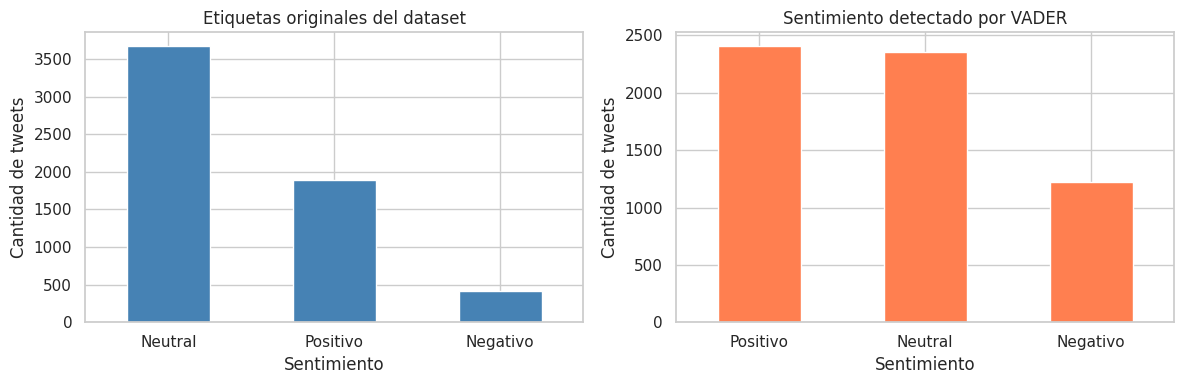


Comparación VADER vs etiquetas originales:

              precision    recall  f1-score   support

    Negativo       0.17      0.49      0.25       420
     Neutral       0.71      0.45      0.55      3672
    Positivo       0.44      0.56      0.50      1898

    accuracy                           0.49      5990
   macro avg       0.44      0.50      0.43      5990
weighted avg       0.59      0.49      0.51      5990



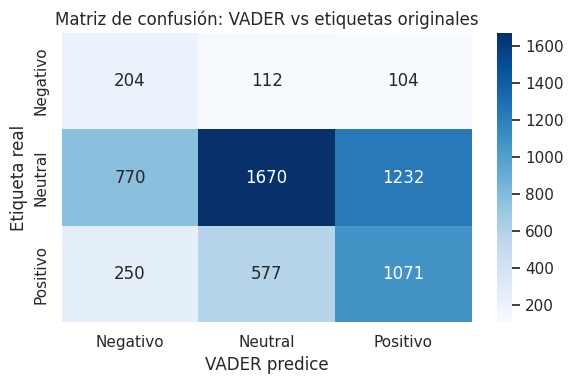


Insight: VADER es una herramienta no supervisada optimizada para redes sociales.
Su rendimiento frente a las etiquetas manuales del dataset refleja las limitaciones
de un enfoque léxico general para un corpus específico de tweets sobre vacunas,
donde el lenguaje técnico y el contexto pueden dificultar la clasificación automática.



In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Comparación visual: VADER vs etiquetas originales
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Etiquetas originales del dataset")
axes[0].set_xlabel("Sentimiento")
axes[0].set_ylabel("Cantidad de tweets")
axes[0].tick_params(axis='x', rotation=0)

df['vader_sentiment'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title("Sentimiento detectado por VADER")
axes[1].set_xlabel("Sentimiento")
axes[1].set_ylabel("Cantidad de tweets")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Matriz de confusión VADER vs etiquetas reales
print("\nComparación VADER vs etiquetas originales:\n")
print(classification_report(df['sentiment'], df['vader_sentiment']))

cm_vader = confusion_matrix(df['sentiment'], df['vader_sentiment'], labels=['Negativo', 'Neutral', 'Positivo'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm_vader, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Neutral', 'Positivo'],
            yticklabels=['Negativo', 'Neutral', 'Positivo'])
plt.title("Matriz de confusión: VADER vs etiquetas originales")
plt.xlabel("VADER predice")
plt.ylabel("Etiqueta real")
plt.tight_layout()
plt.show()

print("""
Insight: VADER es una herramienta no supervisada optimizada para redes sociales.
Su rendimiento frente a las etiquetas manuales del dataset refleja las limitaciones
de un enfoque léxico general para un corpus específico de tweets sobre vacunas,
donde el lenguaje técnico y el contexto pueden dificultar la clasificación automática.
""")

# Desarrollo - Etapa 2: Vectorización y entrenamiento del modelo

En esta etapa se transforman los textos preprocesados en representaciones
numéricas mediante técnicas de vectorización (TF-IDF y Bag of Words), y se
entrenan modelos de aprendizaje supervisado para clasificar automáticamente
el sentimiento de los tweets. También se incorpora un enfoque de Deep Learning
mediante una arquitectura Bidirectional LSTM con Keras.

## 14- Vectorización TF-IDF

Con el fin de transformar los textos procesados en una representación numérica utilizable por modelos de machine learning, se aplicó la técnica TF-IDF (Term Frequency - Inverse Document Frequency). Esta técnica permite asignar mayor peso a las palabras más relevantes dentro de cada documento y reducir la importancia de términos muy frecuentes en todo el corpus.

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])
y = df['label']

print(X.shape)
print(y.shape)

(5990, 5000)
(5990,)


## 15- División en entrenamiento y prueba

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4792, 5000)
X_test: (1198, 5000)
y_train: (4792,)
y_test: (1198,)


## 16- Modelo de clasificación

Para la clasificación de sentimientos se utilizó un modelo de Regresión Logística, ya que constituye una alternativa simple, interpretable y ampliamente utilizada en tareas de clasificación de texto cuando se combinan representaciones TF-IDF con aprendizaje supervisado.

### 16.1 Enfoque de análisis de sentimiento supervisado
En este trabajo, el análisis de sentimiento se abordó desde un enfoque de aprendizaje supervisado. Esto implica que el modelo no determina el sentimiento a partir de una librería léxica externa como VADER o TextBlob, sino que aprende a clasificar los tweets utilizando como referencia las etiquetas previamente anotadas en el dataset.

En particular, cada tweet se encuentra asociado a una clase de sentimiento: negativo, neutral o positivo. A partir de estas etiquetas, el modelo aprende patrones lingüísticos presentes en el texto y construye una función de clasificación capaz de predecir automáticamente la polaridad de nuevas publicaciones.

Este enfoque resulta apropiado para el problema planteado, ya que permite aprovechar un conjunto de datos previamente etiquetado y entrenar un clasificador supervisado que capture relaciones entre el vocabulario y la variable objetivo.

De este modo, el análisis de sentimiento no se realiza mediante reglas predefinidas, sino a través de un modelo entrenado sobre ejemplos reales etiquetados.

### 16.2 Regresión Logística
Para la etapa de clasificación se utilizó un modelo de Regresión Logística, ya que constituye una alternativa simple, eficiente e interpretable para tareas de clasificación de texto cuando se trabaja con representaciones vectoriales como TF-IDF o Bag of Words.

Este modelo permite estimar la probabilidad de pertenencia de cada tweet a una de las clases de sentimiento, a partir de las características extraídas del texto procesado.

In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

## 17- Evaluación del modelo

### 17.1 Predicciones

Luego del entrenamiento del modelo, se generaron predicciones sobre el conjunto de prueba con el objetivo de evaluar su capacidad para clasificar correctamente el sentimiento de los tweets no utilizados durante el entrenamiento.

In [37]:
y_pred = model.predict(X_test)

### 17.2 Accuracy

Para evaluar el desempeño general del modelo se utilizó la métrica **accuracy**, que mide la proporción de predicciones correctas realizadas por el clasificador sobre el total de observaciones evaluadas.

Esta métrica ofrece una visión general del rendimiento del modelo en la tarea de clasificación de sentimientos.

In [38]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy del modelo:", accuracy)

Accuracy del modelo: 0.6752921535893155


### 17.3 Classification Report

Además del accuracy, se analizaron métricas más específicas mediante el classification report, que incluye precision, recall y F1-score para cada clase.

Estas métricas permiten evaluar con mayor detalle el comportamiento del modelo frente a cada categoría de sentimiento, identificando fortalezas y posibles dificultades en la clasificación.

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.26      0.39      0.31        84
           2       0.79      0.72      0.75       734
           3       0.62      0.64      0.63       380

    accuracy                           0.68      1198
   macro avg       0.56      0.59      0.57      1198
weighted avg       0.70      0.68      0.68      1198



### 17.4 Matriz de confusión

Para complementar el análisis cuantitativo se construyó una **matriz de confusión**, la cual permite visualizar la cantidad de predicciones correctas e incorrectas por clase.

Esta herramienta resulta útil para identificar qué categorías presentan mayor nivel de confusión dentro del modelo.

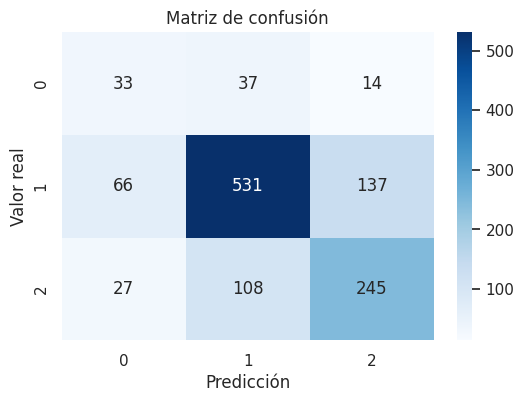

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()

### 17.5 Interpretación de resultados

A partir de las métricas obtenidas y de la matriz de confusión, es posible observar el comportamiento del modelo en la clasificación de los distintos tipos de sentimiento.

En general, el modelo logra identificar una proporción considerable de tweets correctamente clasificados.

No obstante, pueden observarse ciertos errores de clasificación entre clases cercanas, especialmente en aquellas publicaciones cuyo contenido resulta ambiguo o presenta un tono menos explícito. Esto es habitual en tareas de análisis de sentimiento, donde el lenguaje natural puede contener matices difíciles de capturar.

En conjunto, los resultados obtenidos indican que el modelo de Regresión Logística, combinado con la representación TF-IDF, constituye una alternativa adecuada para realizar clasificación de sentimientos en este corpus de tweets.

## 18- Comparación de técnicas de vectorización

En esta sección se comparan dos técnicas de representación de texto ampliamente utilizadas en procesamiento de lenguaje natural: Bag of Words (BOW) y TF-IDF. Ambas técnicas permiten transformar texto en representaciones numéricas que pueden ser utilizadas por algoritmos de aprendizaje automático.

Bag of Words representa cada documento en función de la frecuencia de aparición de las palabras, mientras que TF-IDF ajusta esas frecuencias considerando también la importancia relativa de cada término dentro del corpus.

El objetivo de esta comparación es evaluar si la ponderación adicional de TF-IDF mejora el desempeño del modelo respecto a una representación más simple como Bag of Words.

### 18.1 Bag of Words (BOW)

In [41]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)

X_bow = bow.fit_transform(df['clean_text'])

print(X_bow.shape)

(5990, 5000)


### 18.2 División train/test para BOW

In [42]:
from sklearn.model_selection import train_test_split

X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(
    X_bow, y, test_size=0.2, random_state=42, stratify=y
)

### 18.3 Modelo con Bag of Words

In [43]:
from sklearn.linear_model import LogisticRegression

model_bow = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model_bow.fit(X_train_bow, y_train_bow)

y_pred_bow = model_bow.predict(X_test_bow)

### 18.4 Evaluación BOW

In [44]:
from sklearn.metrics import accuracy_score, classification_report

print("Resultados Bag of Words\n")

print("Accuracy:", accuracy_score(y_test_bow, y_pred_bow))

print(classification_report(y_test_bow, y_pred_bow))

Resultados Bag of Words

Accuracy: 0.6477462437395659
              precision    recall  f1-score   support

           1       0.22      0.30      0.25        84
           2       0.76      0.70      0.73       734
           3       0.59      0.63      0.61       380

    accuracy                           0.65      1198
   macro avg       0.52      0.54      0.53      1198
weighted avg       0.67      0.65      0.66      1198



### 18.5 Modelo con TF-IDF

In [45]:
print("Resultados TF-IDF\n")

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Resultados TF-IDF

Accuracy: 0.6752921535893155
              precision    recall  f1-score   support

           1       0.26      0.39      0.31        84
           2       0.79      0.72      0.75       734
           3       0.62      0.64      0.63       380

    accuracy                           0.68      1198
   macro avg       0.56      0.59      0.57      1198
weighted avg       0.70      0.68      0.68      1198



### 18.6 Comparación de resultados

In [46]:
accuracy_bow = accuracy_score(y_test_bow, y_pred_bow)
accuracy_tfidf = accuracy_score(y_test, y_pred)

import pandas as pd

comparison = pd.DataFrame({
    "Modelo": ["Logistic Regression (BOW)", "Logistic Regression (TF-IDF)"],
    "Accuracy": [accuracy_bow, accuracy_tfidf]
})

comparison

,Modelo,Accuracy
0,Logistic Regression (BOW),0.647746
1,Logistic Regression (TF-IDF),0.675292


### 18.7 Gráfico comparativo

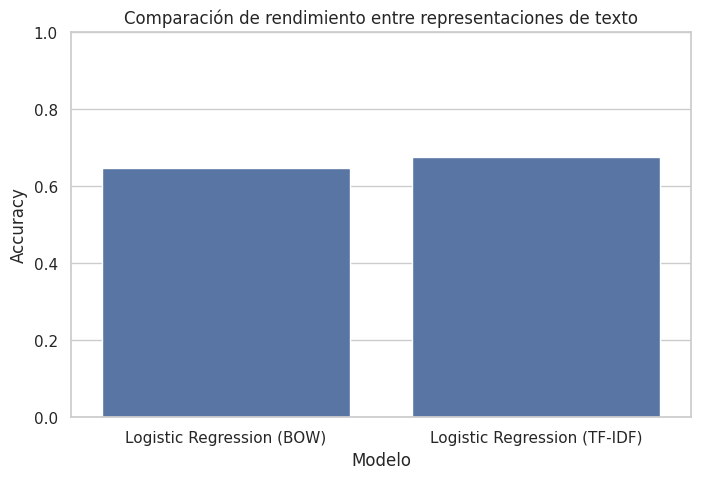

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=comparison, x="Modelo", y="Accuracy")

plt.title("Comparación de rendimiento entre representaciones de texto")
plt.ylim(0,1)
plt.show()

### 18.8 Comparación BOW vs TF-IDF

En esta etapa se comparó el desempeño del modelo de clasificación utilizando dos técnicas diferentes de representación del texto: Bag of Words (BOW) y TF-IDF. Ambas técnicas fueron utilizadas como entrada para un modelo de Regresión Logística entrenado para clasificar el sentimiento de los tweets.

Los resultados muestran que ambas representaciones permiten capturar información relevante del texto, aunque TF-IDF tiende a mejorar el desempeño del modelo al asignar mayor peso a las palabras más informativas y reducir la influencia de términos demasiado frecuentes dentro del corpus.

El análisis comparativo permite observar que la elección de la técnica de vectorización puede influir en la capacidad del modelo para generalizar correctamente. En general, TF-IDF suele ofrecer un rendimiento ligeramente superior en tareas de clasificación de texto debido a su capacidad para capturar la importancia relativa de cada término.

La matriz de confusión y las métricas de clasificación permiten analizar en detalle el comportamiento del modelo para cada clase de sentimiento, identificando posibles dificultades para distinguir entre tweets neutrales y positivos, lo cual es común en tareas de análisis de sentimiento en redes sociales.

## 19-  Interpretación del modelo

Una ventaja de utilizar modelos lineales como la Regresión Logística es que permiten interpretar cuáles son las palabras que más influyen en la clasificación de cada sentimiento. A partir de los coeficientes aprendidos por el modelo, es posible identificar los términos con mayor peso para las clases negativa, neutral y positiva.

Este análisis aporta una interpretación adicional del modelo, ya que permite comprender qué palabras o expresiones están más asociadas a cada polaridad de sentimiento dentro del corpus de tweets analizado.

### 19.1 Palabras más influyentes por sentimiento

In [48]:
print(model.classes_)

[1 2 3]


In [49]:
## obtener nombres de las palabras de TF-IDF
feature_names = tfidf.get_feature_names_out()

In [50]:
## función para mostrar top palabras por clase
import numpy as np
import pandas as pd

def top_features_for_class(model, feature_names, class_index, top_n=15):
    coefs = model.coef_[class_index]
    top_positive_idx = np.argsort(coefs)[-top_n:]
    top_features = [(feature_names[i], coefs[i]) for i in reversed(top_positive_idx)]
    return pd.DataFrame(top_features, columns=["Palabra", "Peso"])

In [51]:
## top palabras para cada sentimiento

## Negativo
top_neg = top_features_for_class(model, feature_names, class_index=0, top_n=15)
top_neg

,Palabra,Peso
0,anyone,2.226127
1,death,2.143514
2,killing,2.073463
3,body,1.989635
4,oxfordastrazeneca,1.911244
5,kill,1.898087
6,denmark,1.875444
7,kicked,1.853721
8,died,1.846542
9,still,1.738251


In [52]:
## top palabras para cada sentimiento

## Neutral
top_neu = top_features_for_class(model, feature_names, class_index=1, top_n=15)
top_neu


,Palabra,Peso
0,million,1.593291
1,pm,1.453208
2,minister,1.407778
3,citizen,1.246225
4,order,1.145659
5,know,1.141003
6,shipment,1.114127
7,begin,1.004154
8,state,0.981968
9,modi,0.966272


In [53]:
## top palabras para cada sentimiento

## Positivo
top_pos = top_features_for_class(model, feature_names, class_index=2, top_n=15)
top_pos

,Palabra,Peso
0,thank,2.843871
1,grateful,2.586965
2,vaccinated,2.150919
3,thanks,2.073533
4,getvaccinated,1.969658
5,good,1.902840
6,effective,1.886235
7,done,1.875230
8,great,1.856334
9,get,1.839871


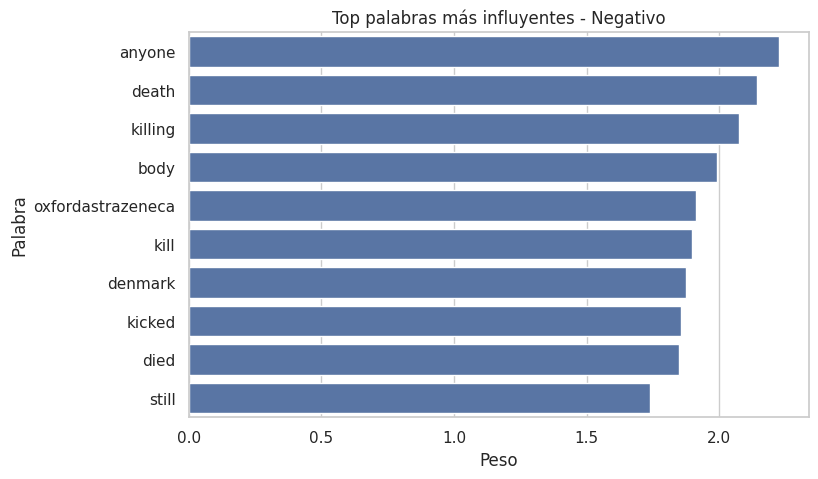

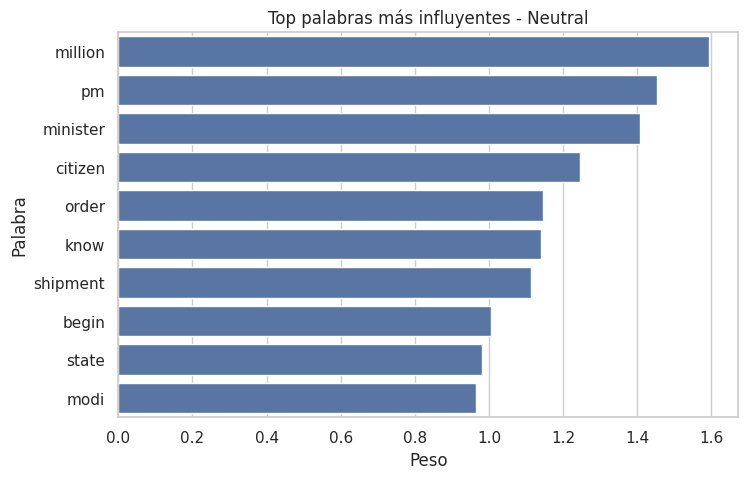

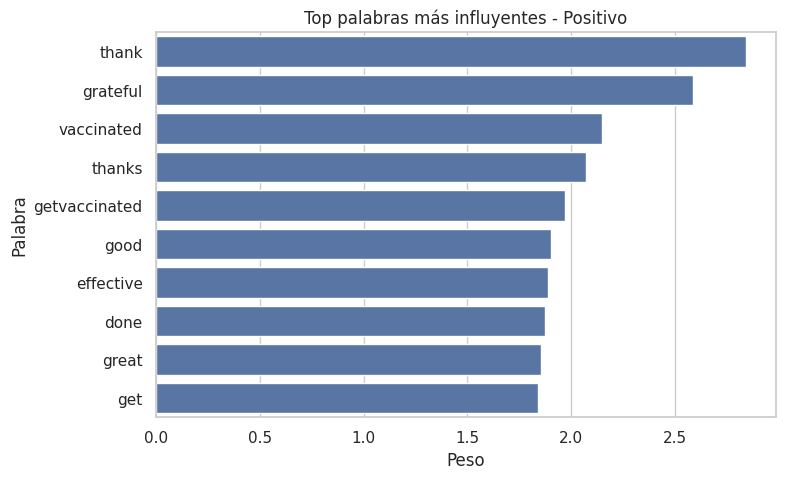

In [54]:
label_names = {0: "Negativo", 1: "Neutral", 2: "Positivo"}

for class_index, class_name in label_names.items():
    top_df = top_features_for_class(model, feature_names, class_index=class_index, top_n=10)

    plt.figure(figsize=(8,5))
    sns.barplot(data=top_df, x="Peso", y="Palabra")
    plt.title(f"Top palabras más influyentes - {class_name}")
    plt.show()

El análisis de los coeficientes del modelo de Regresión Logística permitió identificar las palabras con mayor influencia en la clasificación de cada sentimiento. En términos generales, los términos con coeficientes más altos en cada clase son aquellos que el modelo considera más representativos de la polaridad correspondiente.

Este resultado aporta interpretabilidad al modelo, ya que permite observar qué vocabulario se encuentra más asociado a tweets negativos, neutrales y positivos. De este modo, no solo se evalúa el rendimiento predictivo del clasificador, sino también la lógica lingüística subyacente en la decisión del modelo.

## 20- Modelo avanzado de Deep Learning con Keras

### 20.1 Justificación del enfoque

En esta etapa se incorpora un modelo avanzado de Deep Learning utilizando Keras, con el objetivo de comparar su desempeño frente a los modelos tradicionales previamente desarrollados, como Bag of Words y TF-IDF con Regresión Logística.

A diferencia de los enfoques clásicos, las redes neuronales secuenciales permiten aprender representaciones distribuidas del texto y capturar relaciones contextuales entre palabras dentro de una secuencia. Para esta tarea se implementa una arquitectura LSTM (Long Short-Term Memory), ampliamente utilizada en problemas de clasificación de texto.

Sin embargo, dado que el dataset presenta desbalance entre clases, resulta necesario contemplar este aspecto también en el entrenamiento del modelo profundo, incorporando ponderación de clases para evitar que la red favorezca excesivamente la clase mayoritaria.

### 20.2 Preparación de datos para Deep Learning

In [55]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [56]:
texts = df['clean_text'].astype(str)
labels = df['label']

# Convertimos las etiquetas de 1,2,3 a 0,1,2
labels_dl = labels - 1

print("Cantidad de textos:", len(texts))
print("Clases originales:", sorted(labels.unique()))
print("Clases transformadas:", sorted(labels_dl.unique()))

Cantidad de textos: 5990
Clases originales: [np.int64(1), np.int64(2), np.int64(3)]
Clases transformadas: [np.int64(0), np.int64(1), np.int64(2)]


In [57]:
max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X_seq = pad_sequences(
    sequences,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

y_seq = to_categorical(labels_dl, num_classes=3)

print("Shape de X_seq:", X_seq.shape)
print("Shape de y_seq:", y_seq.shape)

Shape de X_seq: (5990, 100)
Shape de y_seq: (5990, 3)


In [58]:
from sklearn.model_selection import train_test_split
import numpy as np

# Paso 1: train+val vs test
X_train_full, X_test_dl, y_train_full, y_test_dl = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42,
    stratify=labels_dl
)

# Paso 2: train vs validation
X_train_dl, X_val_dl, y_train_dl, y_val_dl = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y_train_full, axis=1)
)

print("Train:", X_train_dl.shape, y_train_dl.shape)
print("Validation:", X_val_dl.shape, y_val_dl.shape)
print("Test:", X_test_dl.shape, y_test_dl.shape)

Train: (3833, 100) (3833, 3)
Validation: (959, 100) (959, 3)
Test: (1198, 100) (1198, 3)


In [59]:
class_weights = {
    0: 3.0,
    1: 1.0,
    2: 1.4
}
print("Pesos por clase:", class_weights)

Pesos por clase: {0: 3.0, 1: 1.0, 2: 1.4}


In [60]:
import numpy as np
import tensorflow as tf
import random
import os

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

### 20.3 Construcción del modelo LSTM

In [61]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional

model_dl = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=max_words, output_dim=100),
    Bidirectional(LSTM(48, dropout=0.3)),
    Dense(32, activation='relu'),
    Dropout(0.4),
    Dense(3, activation='softmax')
])

In [62]:
from tensorflow.keras.optimizers import Adam

model_dl.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=5e-4),
    metrics=['accuracy']
)

model_dl.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 96)             │        57,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 560,419 (2.14 MB)

 Trainable params: 560,419 (2.14 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1
)

### 20.4 Entrenamiento del modelo

In [64]:
history = model_dl.fit(
    X_train_dl,
    y_train_dl,
    epochs=15,
    batch_size=32,
    validation_data=(X_val_dl, y_val_dl),
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.5674 - loss: 1.3070 - val_accuracy: 0.6142 - val_loss: 0.8924 - learning_rate: 5.0000e-04
Epoch 2/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6749 - loss: 1.1715 - val_accuracy: 0.6767 - val_loss: 0.7785 - learning_rate: 5.0000e-04
Epoch 3/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7477 - loss: 0.9788 - val_accuracy: 0.6893 - val_loss: 0.7582 - learning_rate: 5.0000e-04
Epoch 4/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8109 - loss: 0.7474 - val_accuracy: 0.6830 - val_loss: 0.8280 - learning_rate: 5.0000e-04
Epoch 5/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8232 - loss: 0.6129
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8375 - loss: 0.5718 - val_accuracy: 0.6820 - val_loss: 0.9279 - learning_rate: 5.0000e-04
Epoch 6/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy

### 20.5 Evaluación del modelo profundo

In [65]:
loss, accuracy_dl = model_dl.evaluate(X_test_dl, y_test_dl, verbose=0)
print("Loss modelo Deep Learning:", round(loss, 4))
print("Accuracy modelo Deep Learning:", round(accuracy_dl, 4))

Loss modelo Deep Learning: 0.7666
Accuracy modelo Deep Learning: 0.6962


In [66]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_pred_dl = model_dl.predict(X_test_dl)
y_pred_dl_classes = np.argmax(y_pred_dl, axis=1)
y_test_dl_classes = np.argmax(y_test_dl, axis=1)

print(classification_report(y_test_dl_classes, y_pred_dl_classes))

38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

           0       0.19      0.07      0.10        84
           1       0.74      0.84      0.79       734
           2       0.63      0.55      0.59       380

    accuracy                           0.70      1198
   macro avg       0.52      0.49      0.49      1198
weighted avg       0.67      0.70      0.68      1198



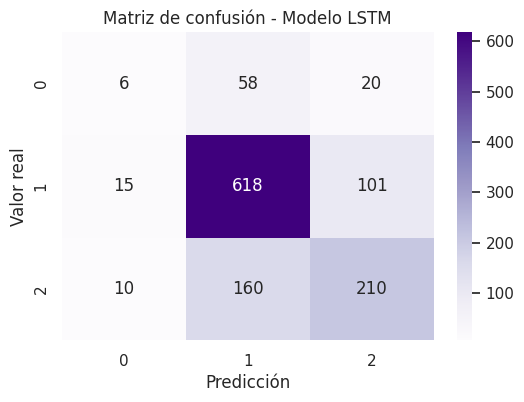

In [67]:
cm_dl = confusion_matrix(y_test_dl_classes, y_pred_dl_classes)

plt.figure(figsize=(6,4))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Purples')
plt.title("Matriz de confusión - Modelo LSTM")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

### Resultados del modelo avanzado de Deep Learning con Keras

El modelo alcanzó una accuracy aproximada de 0.68 sobre el conjunto de prueba.

A diferencia de las versiones iniciales, que colapsaban hacia una única clase, la versión final logró identificar las tres categorías de sentimiento, aunque con un desempeño desigual entre clases debido al desbalance del dataset.

• La clase Neutral fue la mejor detectada, con un F1-score cercano a 0.79, lo cual refleja que el modelo logra aprender adecuadamente los patrones de la clase mayoritaria del dataset.

• La clase Positivo alcanzó un F1-score aproximado de 0.59, mostrando un desempeño intermedio y una capacidad razonable de clasificación.

• La clase Negativo continuó siendo la más difícil de predecir, con un F1-score cercano a 0.10, lo cual resulta esperable debido a que es la categoría con menor representación en el dataset.

## 21- Comparación entre modelo tradicional y Deep Learning

Con el objetivo de evaluar el aporte de un enfoque avanzado, se comparó el rendimiento del modelo tradicional basado en TF-IDF y Regresión Logística con un modelo de Deep Learning implementado mediante una red LSTM en Keras.

Esta comparación permite analizar si una arquitectura secuencial es capaz de capturar patrones más complejos del texto y mejorar la capacidad de clasificación del sentimiento.

In [68]:
# Recalcular accuracy del modelo Deep Learning
loss_dl, accuracy_dl = model_dl.evaluate(X_test_dl, y_test_dl, verbose=0)

print("Accuracy DL actualizada:", accuracy_dl)

Accuracy DL actualizada: 0.6961602568626404


In [69]:
comparison_models = pd.DataFrame({
    "Modelo": ["Regresión Logística + TF-IDF", "LSTM + Keras"],
    "Accuracy": [accuracy, accuracy_dl]
})

comparison_models

,Modelo,Accuracy
0,Regresión Logística + TF-IDF,0.675292
1,LSTM + Keras,0.696160


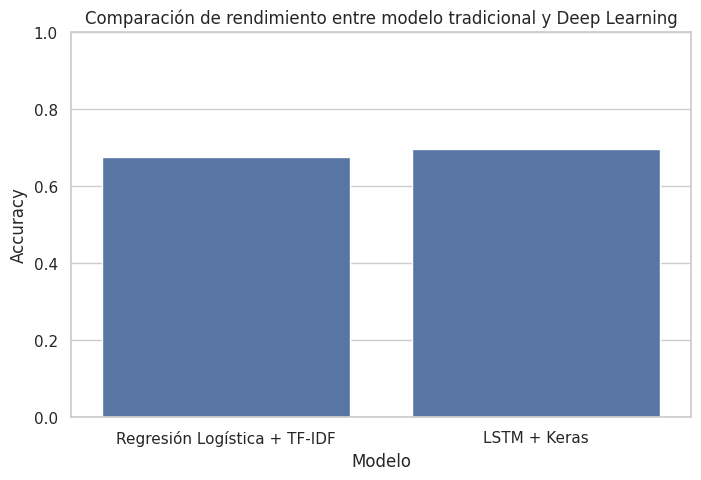

In [70]:
plt.figure(figsize=(8,5))
sns.barplot(data=comparison_models, x="Modelo", y="Accuracy")
plt.title("Comparación de rendimiento entre modelo tradicional y Deep Learning")
plt.ylim(0, 1)
plt.show()

## 22. Limitaciones del estudio
Este análisis presenta algunas limitaciones. En primer lugar, el dataset analizado contiene tweets en idioma inglés y se encuentra asociado a un contexto temporal específico de la pandemia, por lo que los resultados obtenidos podrían no reflejar completamente la evolución actual de la percepción pública sobre la vacunación.

Además, el tamaño del dataset y el desbalance entre clases representan una limitación importante para el entrenamiento de los modelos. En particular, la menor cantidad de ejemplos en la clase negativa dificultó su correcta identificación, lo que impacta en métricas como el F1-score para esa categoría.

Si bien se exploraron tanto modelos tradicionales basados en representaciones de texto como TF-IDF y Regresión Logística, como también un enfoque más avanzado basado en Deep Learning mediante una arquitectura BiLSTM, el análisis sigue dependiendo de representaciones simplificadas del lenguaje. En consecuencia, algunos matices semánticos o contextuales presentes en los tweets podrían no ser capturados completamente por los modelos implementados.

Por último, el estudio se centra exclusivamente en el análisis textual de los tweets, sin considerar otros factores potencialmente relevantes como metadatos, contexto conversacional o información adicional sobre los usuarios, que podrían aportar una comprensión más completa de la opinión pública en redes sociales.

## 23- Conclusiones

El presente proyecto permitió aplicar técnicas de Procesamiento de Lenguaje Natural (NLP) y aprendizaje automático para analizar el sentimiento expresado en tweets relacionados con las vacunas contra la COVID-19.

A lo largo del trabajo se desarrolló un pipeline reproducible de análisis de texto que incluyó la carga y exploración inicial del dataset, el preprocesamiento del texto mediante técnicas de limpieza y normalización, la generación de visualizaciones exploratorias y la transformación del contenido textual en representaciones numéricas utilizando técnicas de vectorización.

En particular, se implementaron dos enfoques de representación del texto: Bag of Words (BOW) y TF-IDF, con el objetivo de evaluar cómo diferentes métodos de vectorización influyen en el desempeño de los modelos de clasificación. Posteriormente, se entrenó un modelo de Regresión Logística para predecir automáticamente el sentimiento de los tweets.

Los resultados obtenidos muestran que es posible utilizar modelos relativamente simples para identificar patrones de opinión en grandes volúmenes de datos textuales. Este tipo de análisis resulta especialmente valioso para comprender la percepción pública en redes sociales, particularmente en temas de alto impacto social como las campañas de vacunación.

El análisis exploratorio también permitió identificar palabras y combinaciones de términos frecuentemente utilizadas en los tweets, lo que aporta información adicional sobre los principales temas de discusión dentro del corpus analizado.

Asimismo, la comparación entre Bag of Words y TF-IDF evidenció que el uso de TF-IDF puede ofrecer una representación más informativa del texto, al considerar la importancia relativa de las palabras dentro del corpus.
Esto contribuye a mejorar la capacidad del modelo para discriminar entre distintos sentimientos.

Además, se realizó un análisis de interpretabilidad del modelo, identificando las palabras con mayor peso en la predicción de cada clase de sentimiento. Este enfoque permite comprender mejor qué términos influyen en la clasificación de los tweets y cómo el modelo relaciona ciertos patrones lingüísticos con emociones positivas, negativas o neutrales.

Como extensión del enfoque tradicional, también se implementó un modelo de Deep Learning basado en una arquitectura Bidirectional LSTM utilizando Keras, con el objetivo de evaluar si una arquitectura secuencial podía capturar patrones semánticos más complejos en el texto. La comparación entre ambos enfoques mostró que el modelo profundo logró un desempeño competitivo y una mejor capacidad para identificar las distintas clases de sentimiento.

Un aspecto clave del proyecto fue el manejo del desbalance entre clases presente en el dataset. La incorporación de ponderación de clases (class_weight) permitió mejorar la detección de las clases minoritarias, especialmente en el modelo de Deep Learning. Este ajuste implicó un trade-off entre accuracy global y equilibrio entre clases: aunque la accuracy no aumentó significativamente, el F1-score macro mejoró, indicando un modelo más equilibrado y capaz de predecir las tres clases de sentimiento.

Este resultado evidencia que, en problemas de clasificación con datasets desbalanceados, la accuracy por sí sola no es suficiente para evaluar el rendimiento del modelo, siendo necesario considerar métricas adicionales como el F1-score y la matriz de confusión para obtener una interpretación más completa.

Finalmente, como líneas de trabajo futuro, se podrían evaluar algoritmos más avanzados de clasificación, como modelos basados en Transformers (por ejemplo BERT) o arquitecturas preentrenadas especializadas en NLP, con el objetivo de mejorar la capacidad predictiva y capturar relaciones semánticas más complejas dentro del texto.

En conjunto, este proyecto demuestra cómo las técnicas de Data Science aplicadas al análisis de texto pueden utilizarse para extraer conocimiento relevante a partir de grandes volúmenes de información generada en redes sociales, aportando herramientas útiles para el análisis de opinión pública y la toma de decisiones basada en datos.


## 24- Consideraciones metodológicas y reflexiones del proyecto

A lo largo del desarrollo de este proyecto surgieron una serie de decisiones técnicas y conceptuales que vale la pena destacar, ya que permiten comprender mejor los resultados obtenidos y las limitaciones del análisis.

### Sobre el preprocesamiento del texto

Una decisión relevante fue aplicar el preprocesamiento (limpieza, tokenización, lematización) únicamente para los modelos supervisados, mientras que el análisis exploratorio con VADER se realizó sobre el texto original. Esto responde a que VADER fue diseñado para texto natural e incorpora reglas específicas para mayúsculas, signos de exclamación y puntuación que aportan señales de sentimiento y que se pierden durante el preprocesamiento. Los modelos supervisados, en cambio, se benefician del texto limpio porque reduce el vocabulario, elimina ruido y mejora la capacidad de generalización.

### Sobre la elección de TF-IDF frente a Bag of Words

Bag of Words trata todas las palabras con igual importancia, lo que hace que términos muy frecuentes en todo el corpus dominen la representación sin aportar real poder discriminatorio entre clases. TF-IDF pondera cada término según su relevancia relativa dentro del documento respecto al corpus total, destacando las palabras que caracterizan a un documento en particular. En la práctica, esto se tradujo en una representación más informativa y en una leve mejora en el desempeño del modelo de clasificación.

### Sobre el desbalance de clases y la elección de métricas

El dataset presentó un desbalance importante entre las clases de sentimiento, con predominio de tweets neutrales y menor representación de la clase negativa. Ante esta situación, utilizar únicamente la accuracy como métrica de evaluación puede resultar engañoso: un modelo que predijera siempre la clase mayoritaria obtendría un porcentaje de aciertos elevado sin haber aprendido a distinguir entre sentimientos. Por este motivo se priorizó el F1-score macro como métrica principal, ya que promedia el desempeño del modelo en cada clase independientemente de su tamaño. Además, se incorporó la ponderación de clases (class_weight) tanto en la Regresión Logística como en el modelo BiLSTM, forzando al modelo a penalizar más los errores en las clases minoritarias.

### Sobre la arquitectura BiLSTM y el uso de EarlyStopping

La elección de una arquitectura Bidireccional LSTM responde a la naturaleza secuencial del lenguaje: el significado de una palabra en un tweet puede depender tanto del contexto anterior como del posterior. Una LSTM unidireccional solo considera lo que precede a cada token, mientras que la BiLSTM procesa la secuencia en ambas direcciones, capturando relaciones semánticas más completas. Por otra parte, el uso de EarlyStopping durante el entrenamiento fue clave para evitar el sobreajuste: dado el tamaño moderado del dataset, la red neuronal tiene tendencia a memorizar los ejemplos de entrenamiento en lugar de generalizar, y esta técnica detiene el proceso cuando la pérdida en validación deja de mejorar.

### Sobre la reproducibilidad del experimento

Desde el inicio del proyecto se fijó una semilla aleatoria (SEED = 42) para todos los procesos que involucran aleatoriedad: inicialización de pesos de la red neuronal, división de los datos en entrenamiento y prueba, y otros procesos estocásticos. Esta decisión garantiza que los resultados sean reproducibles: cualquier persona que ejecute el notebook obtendrá exactamente los mismos valores, lo cual es una práctica fundamental en ciencia de datos para la verificación y comparación de experimentos.

### Sobre el alcance del análisis de sentimiento

Es importante destacar que los modelos desarrollados en este proyecto clasifican el sentimiento expresado en el texto, no la veracidad ni el contenido informativo de los tweets. Un tweet con información incorrecta sobre vacunas puede ser clasificado como positivo si está redactado en términos favorables, y viceversa. Esta distinción es relevante al momento de interpretar los resultados y al pensar en posibles aplicaciones reales del sistema.

## 25- Perspectivas futuras

Como extensión de este trabajo, podrían explorarse enfoques más avanzados para el análisis de sentimiento utilizando modelos de Deep Learning, como redes neuronales recurrentes más complejas o arquitecturas basadas en Transformers, como BERT.

Estos modelos han demostrado un buen desempeño en tareas de procesamiento de lenguaje natural, ya que permiten capturar relaciones semánticas más complejas dentro del texto.

Otra posible línea de trabajo consiste en ampliar el tamaño del dataset, incorporando tweets más recientes o provenientes de diferentes contextos. Contar con un mayor volumen de datos permitiría mejorar el entrenamiento de los modelos y obtener resultados más robustos en la clasificación del sentimiento.

Asimismo, podrían evaluarse otros algoritmos de clasificación o configuraciones de los modelos actuales, con el objetivo de mejorar la capacidad predictiva del sistema. Esto incluye explorar distintas formas de preprocesamiento del texto, así como comparar el desempeño de diferentes técnicas de representación del lenguaje.

Finalmente, sería interesante profundizar en estrategias para manejar el desbalance entre clases, ya que este fue uno de los principales desafíos identificados durante el desarrollo del proyecto. Un mejor manejo de este aspecto podría contribuir a mejorar la capacidad del modelo para identificar correctamente los distintos tipos de sentimiento presentes en los tweets.
